# Test 2b - Merge, Aggregate, Visualize

## Introduction

This problem tests your ability to merge, aggregate, and visualize data.
You'll work with realistic business data to answer questions about product profitability.

Before submitting, ensure your notebook:

- Includes your verification info (Banner ID and code) as the first cell
- Runs completely with "Kernel → Restart & Run All"
- Shows your work (don't just print final answers)
- Includes your interpretation responses at the end

## Dataset: Bean & Brew Coffee Shop

You've been hired to analyze sales data for Bean & Brew, a local coffee shop chain with three locations. The owner wants to understand which products are most profitable and how profitability varies across locations.

There are two data files:

- `sales.csv` - Individual transaction records
  - `transaction_id`: Unique transaction identifier
  - `timestamp`: Date and time of purchase (format: 'YYYY-MM-DD HH:MM:SS')
  - `location`: Store location ('Downtown', 'Campus', 'Suburb')
  - `product_id`: Product identifier (links to products table)
  - `quantity`: Number of units sold
  - `revenue`: Total revenue from transaction
  - `payment_method`: Payment type ('Cash', 'Credit', 'Mobile')
  - `loyalty_member`: Boolean indicating if customer is loyalty program member
- `products.csv` - Product catalog
  - `product_id`: Unique product identifier
  - `name`: Product name
  - `category`: Product category ('Coffee', 'Tea', 'Pastry', 'Sandwich')
  - `cost`: Cost to make/acquire one unit (for profit calculation)

The dataset contains two weeks of sales data (approximately 3,000 transactions) across 18 products. It includes both regular and premium items in each category.

We are interested in learning which product categories generate the most profit, and how does profitability vary across locations? Complete the following tasks to answer those questions and more.

## Scoring

Total: 30 points (+ 5 bonus)

- Tasks 1-6: 18 points
- Interpretation (Questions 1-4): 12 points
- Bonus: 5 points (optional)

## Generate Your Dataset

Before starting the analysis, you need to generate your unique dataset using your Banner ID.

1. Open a terminal in the folder containing `generate_test2b_data.py`
2. Activate your conda virtual environment
3. Run: `python generate_test2b_data.py`
4. Enter your 9-digit Banner ID when prompted (you'll enter it twice to confirm)

The script will create two files in the `data/` folder:

- `data/products.csv` - Product catalog
- `data/sales.csv` - Transaction records

Important: At the end, the script displays a verification block like this:

```
======================================================================
DATA VERIFICATION INFORMATION
======================================================================
banner id:          904123456
verification code:  5e0dXXXXXXXX
======================================================================
```

Copy the banner id and verification code lines and paste them into the cell below. This is required for submission.

```
======================================================================
DATA VERIFICATION INFORMATION
======================================================================
banner id:          904433121
verification code:  9af9156aeb93
======================================================================
```

## Setup: Load the Data

Run the cell below to load the data. The code is provided for you.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data (provided)
sales = pd.read_csv('data/sales.csv', parse_dates=['timestamp'])
products = pd.read_csv('data/products.csv')

print(f"Sales: {len(sales)} transactions")
print(f"Products: {len(products)} items in catalog")
print()
print("Sales preview:")
sales.head()

Sales: 2960 transactions
Products: 18 items in catalog

Sales preview:


,transaction_id,timestamp,location,product_id,quantity,revenue,payment_method,loyalty_member
0,1000,2025-11-07 06:01:00,Campus,101,1.0,2.71,Credit,False
1,1002,2025-11-07 06:06:00,Campus,101,2.0,5.04,Credit,False
2,1004,2025-11-07 06:09:00,Downtown,108,1.0,3.40,Mobile,False
3,1005,2025-11-07 06:26:00,Campus,113,1.0,3.27,Mobile,False
4,1003,2025-11-07 06:36:00,Downtown,108,1.0,3.01,Credit,False


In [2]:
# Products catalog
products

,product_id,name,category,cost
0,101,Espresso,Coffee,1.2
1,102,Cappuccino,Coffee,1.8
2,103,Latte,Coffee,1.9
3,104,Americano,Coffee,1.0
4,105,Cold Brew,Coffee,1.5
5,106,Nitro Cold Brew,Coffee,2.5
6,107,Green Tea,Tea,0.8
7,108,Chai Latte,Tea,1.2
8,109,Herbal Tea,Tea,0.7
9,110,Premium Matcha,Tea,2.2


## Task 1: Data Quality Check

Investigate the sales data quality and coverage. Your code should answer the following questions:

1. How many missing values are in each column?
2. How many unique product IDs appear in the sales data? Compare this to the catalog size.
3. What is the date range (earliest and latest transaction)?

### Your Code

In [3]:
# Task 1: use isna(), nunique(), min/max on timestamp

# Find the number of missing values per column
missing_per_col : pd.core.frame.DataFrame = sales.isna().sum()
print(missing_per_col)

# Find the number of unique product IDs and compare it to the number of products
unique_prod_ids : int = sales['product_id'].nunique()
num_prods : int = len(products)
print(f"\nThere are {unique_prod_ids} in the sales DataFrame, while there are {num_prods} products in the products DataFrame.")

# Find the earliest and latest transactions
earliest_transaction = sales['timestamp'].min()
latest_transaction = sales['timestamp'].max()
print(f"\nThe earliest transaction occured at {earliest_transaction}, while the latest transcation occured at {latest_transaction}")

transaction_id    0
timestamp         0
location          0
product_id        0
quantity          5
revenue           3
payment_method    0
loyalty_member    0
dtype: int64

There are 21 in the sales DataFrame, while there are 18 products in the products DataFrame.

The earliest transaction occured at 2025-11-07 06:01:00, while the latest transcation occured at 2025-11-20 21:53:00


## Task 2: Merge Sales with Products

Merge the sales and products DataFrames to add product information (name, category, cost) to each transaction.

### Your Code

In [4]:
# Task 2: use pd.merge() with appropriate join type

# Merge the sales and products DataFrames to add product info to each transaction
sales_with_products : pd.core.frame.DataFrame = pd.merge(sales, products, how="left", on="product_id")

print(sales_with_products.head())

   transaction_id           timestamp  location  product_id  quantity  \
0            1000 2025-11-07 06:01:00    Campus         101       1.0   
1            1002 2025-11-07 06:06:00    Campus         101       2.0   
2            1004 2025-11-07 06:09:00  Downtown         108       1.0   
3            1005 2025-11-07 06:26:00    Campus         113       1.0   
4            1003 2025-11-07 06:36:00  Downtown         108       1.0   

   revenue payment_method  loyalty_member        name category  cost  
0     2.71         Credit           False    Espresso   Coffee   1.2  
1     5.04         Credit           False    Espresso   Coffee   1.2  
2     3.40         Mobile           False  Chai Latte      Tea   1.2  
3     3.27         Mobile           False       Scone   Pastry   1.1  
4     3.01         Credit           False  Chai Latte      Tea   1.2  


## Task 3: Verify the Merge

After merging, verify that the merge worked correctly:

1. Compare the shape of the merged DataFrame to the original sales data
2. Check if any rows have missing values in the product columns (name, category, cost)
3. If there are missing values, identify which product_id(s) are causing the problem

### Your Code

In [5]:
# Task 3: check shape, isna() on product columns, filter to find problem IDs

# Compare the DataFrame shapes
sales_shape = sales.shape
merged_shape = sales_with_products.shape
print(f"The original DataFrame has a shape of {sales_shape} and the merged DataFrame has a shape of {merged_shape}")

# Check for missing rows in the product columns
print("\n Missing Values per Product Column:")
print(sales_with_products[['name', 'category', 'cost']].isna().sum())

# Identify problematic product_ids
problem_ids : pd.core.series.Series = sales_with_products.loc[sales_with_products['name'].isna(), 'product_id']
print("\nProblematic IDs:")
print(problem_ids.unique())

The original DataFrame has a shape of (2960, 8) and the merged DataFrame has a shape of (2960, 11)

 Missing Values per Product Column:
name        13
category    13
cost        13
dtype: int64

Problematic IDs:
[199 201 200]


## Task 4: Profit by Category

First, calculate profit for each transaction: `profit = revenue - (cost × quantity)`

Then summarize profitability by product category. Your code should return a table that shows both total profit and number of transactions for each category. Sort it by total profit (highest first).

### Your Code

In [6]:
# Task 4: create profit column, then groupby with .agg()

# Compute and add the profit column
sales_with_products['profit'] = sales_with_products['revenue'] - (sales_with_products['cost'] * sales_with_products['quantity'])

# Summarize profitability by each product category, sorted from highest to lowest profit
profit_summation : pd.core.frame.DataFrame = (sales_with_products.groupby('category')['profit']
                    .agg(['sum', 'count'])
                    .rename(columns={'sum':'Total Profit', 'count':'Transactions'})
                    .sort_values(by='Total Profit', ascending=False))

print("\nProfit Summary:")
print(profit_summation)


Profit Summary:
          Total Profit  Transactions
category                            
Sandwich       5060.27           711
Coffee         2544.13          1024
Pastry         1703.18           589
Tea             873.70           615


## Task 5: Profit by Category and Location

Analyze how profitability varies by both category and location. Your code should produce a table that shows the following for every combination of category and location:

- Total profit
- Average profit per transaction
- Number of transactions

Display the results as a flat table (i.e., without a nested/hierarchical index).

### Your Code

In [7]:
# Task 5: groupby multiple columns, .agg() with dict, reset_index()

# Examine profitability by category and location
profit_by_cat_location : pd.core.frame.DataFrame = (sales_with_products.groupby(['category', 'location'])['profit']
                                                    .agg(['sum', 'mean', 'count'])
                                                    .reset_index()
                                                    .rename(columns={'sum':'Total Profit', 'mean':'Avg. Profit/Transaction', 'count':'Transactions'})
                                                    .sort_values(by='Total Profit', ascending=False))
print("\nProfitby Location Summary:")
print(profit_by_cat_location)


Profitby Location Summary:
    category  location  Total Profit  Avg. Profit/Transaction  Transactions
7   Sandwich  Downtown       3040.48                 7.980262           381
0     Coffee    Campus       1178.60                 2.078660           567
8   Sandwich    Suburb       1174.06                 6.670795           176
1     Coffee  Downtown       1172.98                 3.144718           373
6   Sandwich    Campus        845.73                 5.491753           154
4     Pastry  Downtown        657.73                 3.594153           183
3     Pastry    Campus        646.39                 2.476590           261
5     Pastry    Suburb        399.06                 2.752138           145
10       Tea  Downtown        331.85                 1.784140           186
11       Tea    Suburb        328.40                 1.272868           258
9        Tea    Campus        213.45                 1.248246           171
2     Coffee    Suburb        192.55                 2.29226

Create a bar chart showing total profit by product category. Use seaborn and ensure that the result:

- Has clearly labeled categories
- Includes a descriptive title
- Makes it clear which category is most/least profitable

### Your Code

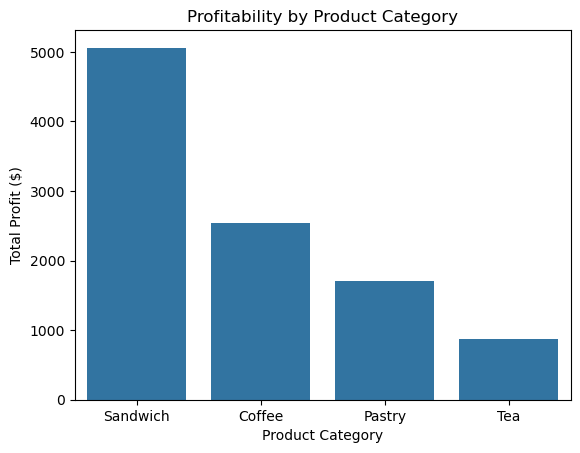

In [8]:
# Task 6: use sns.barplot() with aggregated data

sns.barplot(x='category', y='Total Profit', data=profit_summation)
plt.title("Profitability by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Profit ($)")
plt.show()

## Interpretation

Concisely answer the following questions based on your analysis.


1. What might go wrong if you did not verify the merge in Task 3 before proceeding with the analysis?
2. In Tasks 4 and 5, you aggregated data at different levels of detail (by category, then by category and location). How did this change what you could learn from the data?
3. Reflect on the patterns you discovered in your analysis. What valuable insights did your work generate?
4. The coffee shop owner asks: "Based on your analysis, what's the single most important thing I should do to improve profitability?" Provide a specific, actionable recommendation. Justify your recommendation with evidence from your analysis (include specific numbers from your results). Also, suggest additional analysis that you feel might be worthwhile.

### Your Answers

### Student Response
1. For Task 3, had I not verified the merge, I could have proceeded with an inaccurate dataset. For example, had I incorrectly used the `how="right"` argument for the merge, rows in `sales` that do not have corresponding `product_id` enties in `products` would have been excluded. This means I would have lost 13 rows in the DataFrame. While this shouldn't affect data analysis due to Pandas' use of `NaN`, it could affect data correction later. Furthermore, had I selected the wrong parameter for the `on=` argument, the table could have had incorrect matches for values in sales mapped to values in products, which would have produced inaccurate results in subsequent analyses.
2. For Task 4, I aggregated data by category, which provided profit by product category sold. For Task 5, the same analysis was done, with the addition of the location included. This meant that I could not only analyze the most profitability of the products, but I could also see _where_ it was that these products were selling the best, and which locations account for which portion of the profits by category. For example, we see in Task 4 that the Sandwich is the most profitable product, but by expanding our analysis to include aggregated data by location _and_ category, we can see that the Sandwiches sold at the Downtown location account for a heavy majority of this Sandwich profit.
3. An interesting insight is that coffee sold at the Campus location is making more net profit for the business than the Sandwich is at the Suburb or Campus locations. A standalone analysis of profit summary could lead one to believe that Sandwiches are the top net profit earner for each location, however, the category and location summary provides an analysis that shows us that coffee sales at the Campus location account for a majority of the Campus profit. While that is an example of a more specific insight, in general, the analysis above could provide the owner of the business with data that would show how to prioritize sales for at each location. Instead of doing a sandwich special across the business locations, the analsyis above shows us that other products generate more net profit at the Campus on a volume basis and therefore, it may be wise to prioritize coffee sales at this location to tap into the larger transaction volume at this location, for this product category.
4. My reccomendation would be to offer a "Sandwich + Coffee" special at the Campus location. Other locations have a much higher ratio of sandwiches to coffees sold (Suburb: 176/84 (2.095), Downtown: 381/373 (1.021), Campus:  154/567 (.271)), which means that the campus location has a much higher untapped volume of customers that are not purchasing sandwiches. Furthermore, given that the Campus and Downtown locations have similar volume (1153 vs. 1126 transactions, respectively), this suggests that the sandwhich sales of the Campus location could be much higher by tapping into the coffee purchaser volume. Additionally, the Suburb location has 663 total transactions, compared to the 1153 of the Campus location, we see that the Suburb location has just over half of the volume seen by the Campus location (57.5%), yet sells more sandwiches (176 at Suburb vs. 154 at Campus), which further suggests that there is an untapped customer base for sandwiches at the Campus location. By combining the volume of coffee sales this location, along with the profit per sandwich sold, the owner could tap into the high volume of coffee purchasers the Campus location sees by selling a high-profit product along with the coffee, potentially increasing the volume of sandwich sales by a significant margin. An additional analysis that could take place that would be worthwhile would be an analysis on said proposed discount. The number of additional sandwich sales could be estimated as a function of the price-point for the proposed combo special. Though this would be difficult to estimate, one could use historical data to relate sales of certain products as a function of their prices. The price that optimizes profitability for the combo special could then be determined by examining volume vs. revenue at each point along the price vs. estimated sales curve, allowing computation of an estimated profit figure at each point. This would allow the owner of the store to adequately price the combo special to maximize profits and increased sandwich sales volume.

## Bonus: Time-Based Analysis (Optional)

For extra credit, investigate a time-based question of your choosing. Examples of questions you could explore include:

- Do sales patterns differ between weekdays and weekends?
- Which hours are busiest at each location?
- Is there a day of the week that stands out for profitability?

For full credit you must:

- State your question clearly
- Show your analysis code
- Summarize what you found in 2-3 sentences

In [9]:
# Bonus: Your time-based analysis here

## Question to answer: Are day normalized coffee sales at all locations higher (by volume) on weekday or weekend mornings?
# Note: Mornings are defined as hours 6-9, inclusive
# Note: 

# Create the bool masks for identifying weekday and, by extension, weekend morning sales
isWeekdayMorning : pd.core.series.Series = ((sales_with_products['timestamp'].dt.dayofweek <= 4) & (sales_with_products['timestamp'].dt.hour.isin([6,7,8,9])))

# Create a new derived column called isWeekdayMorning
sales_with_products['isWeekdayMorning'] = isWeekdayMorning.astype('category')

# Set type to category
#sales_with_products['isWeekdayMorning'] = sales_with_products['isWeekdayMorning']

# Query the data for coffee sales
week_weekend_profit_summary = (sales_with_products.query("category == 'Coffee'", engine="python")
                               .groupby('isWeekdayMorning', observed=False)['isWeekdayMorning']
                               .count()
                               .astype('float64'))

print("\nTotal Sales:")
print(week_weekend_profit_summary)


# Get the number of weekdays and weekend days in the dataset to use for normalization
unique_days : pd.core.series.Series = (sales_with_products['timestamp'].dt.date
                                      .drop_duplicates()
                                      .astype('datetime64[ns]'))

n_weekdays_in_data : int = unique_days[unique_days.dt.dayofweek <= 4].count()
n_weekends_in_data : int = unique_days[unique_days.dt.dayofweek > 4].count()


# Normalize the transaction count by number of days in weekday/weekend period
week_weekend_profit_summary.loc[True] = week_weekend_profit_summary.loc[True]/n_weekdays_in_data
week_weekend_profit_summary.loc[False] = week_weekend_profit_summary.loc[False]/n_weekends_in_data

print("\nNormalized Sales:")
print(week_weekend_profit_summary)


Total Sales:
isWeekdayMorning
False    590.0
True     439.0
Name: isWeekdayMorning, dtype: float64

Normalized Sales:
isWeekdayMorning
False    147.5
True      43.9
Name: isWeekdayMorning, dtype: float64


### Your Findings

## Student Findings:
### Question: Are day normalized coffee sales at all locations higher (by transaction volume) on weekday or weekend mornings?

### Answer:
The normalized sales of coffee products on weekday hours 6-9 (inclusive) are far lower than the weekend morning hours sales. Furthermore, the total number of weekend transactions was higher than the number of weekday transactions. The weekend mornings in the data had 590 sales, normalized by the 4 weekend days in the dataset, this comes out to 147.5 sales on average. The weekday mornings in the data had 439 sales, normalized by the 10 weekend days in the dataset, this comes out to 43.9 sales on average. 

##### Note: Normalized in this context means that the total weekday sales count was divided by 10, 4 for the weekend to account for the number of each day type's pbservations in the dataset

## Submission

Ensure your notebook:

- Has the verification block (Banner ID and code) as the first cell
- Runs completely from top to bottom without errors
- Shows all task outputs clearly
- Includes all interpretation responses
- Is saved and committed to your repository

Follow the submission instructions on Canvas to submit your work.